# 4 Qubits

## Baseline 

In [ ]:
مدل پایه روی داده‌های مستقل (دوران تصادفی) آموزش می‌بیند.
ارزیابی روی دو نوع داده تست انجام می‌شود: داده مستقل و داده همبسته با RZZ.
نمودارها و شاخص‌ها (شاخص ها) طوری نمایش داده می‌شوند که قابلیت مقایسه مستقیم با مدل‌های پیچیده‌تر در آینده وجود داشته باشد.

In [1]:
# ================================
# IMPORTS
# ================================
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, ReadoutError

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ================================
# METRICS
# ================================
def kl_divergence(p, q):
    return np.sum(p * np.log((p + 1e-10) / (q + 1e-10)))

def fidelity(p, q):
    return (np.sum(np.sqrt(p * q)))**2

def l1_error(p, q):
    return np.sum(np.abs(p - q))

# ================================
# CIRCUIT BUILDERS
# ================================
def build_circuit_independent(thetas):
    qc = QuantumCircuit(4, 4)
    for i in range(4):
        qc.ry(thetas[i], i)
    qc.measure([0,1,2,3], [0,1,2,3])
    return qc

def build_correlated_circuit_rzz(thetas, theta_rzz=np.pi/2):
    qc = QuantumCircuit(4, 4)
    for i in range(4):
        qc.ry(thetas[i], i)
    for j in range(4):
        for k in range(j+1, 4):  # هر جفت یکبار
            qc.rzz(theta_rzz, j, k)
    qc.measure([0,1,2,3], [0,1,2,3])
    return qc

def counts_to_probs_4q(counts):
    probs = np.zeros(16)
    for bitstring, count in counts.items():
        probs[int(bitstring, 2)] = count
    return probs / np.sum(probs)

# ================================
# NOISE MODEL
# ================================
def create_noise_model(p01, p10):
    noise_model = NoiseModel()
    readout_error = ReadoutError([[1-p01, p01], [p10, 1-p10]])
    for q in range(4):
        noise_model.add_readout_error(readout_error, [q])
    return noise_model

# ================================
# SIMULATOR WRAPPER
# ================================
def get_probs(qc_func, thetas, noise_model=None, shots=1024):
    qc = qc_func(thetas)
    sim = AerSimulator(noise_model=noise_model)
    qc_t = transpile(qc, sim)
    result = sim.run(qc_t, shots=shots).result()
    counts = result.get_counts()
    return counts_to_probs_4q(counts)

# ================================
# DATA GENERATION
# ================================
def generate_dataset(num_samples, qc_func, noise_range=(0.05,0.15)):
    X, Y, Thetas = [], [], []
    for _ in range(num_samples):
        thetas = np.random.uniform(0, np.pi, size=4)
        p01 = np.random.uniform(*noise_range)
        p10 = np.random.uniform(*noise_range)
        noise_model = create_noise_model(p01, p10)
        p_ideal = get_probs(qc_func, thetas, noise_model=None)
        p_noisy = get_probs(qc_func, thetas, noise_model=noise_model)
        X.append(p_noisy)
        Y.append(p_ideal)
        Thetas.append(thetas)
    return np.array(X), np.array(Y), np.array(Thetas)

In [2]:
# ================================
# GENERATE TRAIN & TEST DATA
# ================================
print("Generating TRAIN dataset (independent)...")
X_train, Y_train, theta_train = generate_dataset(5000, build_circuit_independent)

print("Generating TEST dataset (independent)...")
X_test_ind, Y_test_ind, theta_test_ind = generate_dataset(1500, build_circuit_independent)

print("Generating TEST dataset (RZZ correlated)...")
X_test_zz, Y_test_zz, theta_test_zz = generate_dataset(1500, build_correlated_circuit_rzz)
print("Generating dataset completed")
#==================================
# Combined test dataset
X_test_combined = np.vstack([X_test_ind, X_test_zz])
Y_test_combined = np.vstack([Y_test_ind, Y_test_zz])
theta_test_combined = np.vstack([theta_test_ind, theta_test_zz])

Generating TRAIN dataset (independent)...
Generating TEST dataset (independent)...
Generating TEST dataset (RZZ correlated)...
Generating dataset completed


## SAVE DATA

In [3]:
# SAVE DATA
import numpy as np

# ================================
# ذخیره دیتاست مستقل به صورت txt
# ================================
# # Flatten هر sample و ذخیره
np.savetxt("X_train_ind.txt", X_train.reshape(X_train.shape[0], -1))
np.savetxt("Y_train_ind.txt", Y_train.reshape(Y_train.shape[0], -1))
np.savetxt("theta_train_ind.txt", theta_train)

np.savetxt("X_test_ind.txt", X_test_ind.reshape(X_test_ind.shape[0], -1))
np.savetxt("Y_test_ind.txt", Y_test_ind.reshape(Y_test_ind.shape[0], -1))
np.savetxt("theta_test_ind.txt", theta_test_ind)

# # ================================
# # ذخیره دیتاست RZZ به صورت txt
# # ================================
np.savetxt("X_test_zz.txt", X_test_zz.reshape(X_test_zz.shape[0], -1))
np.savetxt("Y_test_zz.txt", Y_test_zz.reshape(Y_test_zz.shape[0], -1))
np.savetxt("theta_test_zz.txt", theta_test_zz)

np.savetxt("X_test_combined.txt", X_test_combined.reshape(X_test_combined.shape[0], -1))
np.savetxt("Y_test_combined.txt", Y_test_combined.reshape(Y_test_combined.shape[0], -1))
np.savetxt("theta_test_combined.txt", theta_test_combined)
#########################33
# # فرض کنیم num_samples_train = 4000 و num_samples_test = 1000
X_train = np.loadtxt("X_train_ind.txt").reshape(-1, 16)
Y_train = np.loadtxt("Y_train_ind.txt").reshape(-1, 16)
theta_train = np.loadtxt("theta_train_ind.txt").reshape(-1, 4)

X_test_ind = np.loadtxt("X_test_ind.txt").reshape(-1, 16)
Y_test_ind = np.loadtxt("Y_test_ind.txt").reshape(-1, 16)
theta_test_ind = np.loadtxt("theta_test_ind.txt").reshape(-1, 4)

X_test_zz = np.loadtxt("X_test_zz.txt").reshape(-1, 16)
Y_test_zz = np.loadtxt("Y_test_zz.txt").reshape(-1, 16)
theta_test_zz = np.loadtxt("theta_test_zz.txt").reshape(-1, 4)

X_test_combined = np.loadtxt("X_test_combined.txt").reshape(-1,16)
Y_test_combined = np.loadtxt("Y_test_combined.txt").reshape(-1,16)
theta_test_combined = np.loadtxt("theta_test_combined.txt").reshape(-1,4)

In [4]:
class MLP_4Q(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(16, 128),
            nn.ReLU(),
            
            nn.Linear(128, 256),
            nn.ReLU(),
            
            nn.Linear(256, 128),
            nn.ReLU(),
            
            nn.Linear(128, 16),
            nn.Softmax(dim=1)
        )
    
    def forward(self, x):
        return self.net(x)

In [6]:
# ================================
# DATA LOADERS
# ================================
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train,dtype=torch.float32),
                  torch.tensor(Y_train,dtype=torch.float32)),
    batch_size=64, shuffle=True
)

In [7]:
# ================================
# TRAINING
# ================================
model_base = MLP_4Q()
criterion = nn.KLDivLoss(reduction="batchmean")
optimizer = optim.Adam(model_base.parameters(), lr=1e-3)

epochs = 101
train_losses, test_losses = [], []

for epoch in range(epochs):
    model_base.train()
    total_loss = 0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model_base(x_batch)
        loss = criterion(torch.log(preds + 1e-8), y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_losses.append(total_loss / len(train_loader))
    
    model_base.eval()
    with torch.no_grad():
        preds_test = model_base(torch.tensor(X_test_ind, dtype=torch.float32))
        test_loss = criterion(torch.log(preds_test + 1e-8),
                              torch.tensor(Y_test_ind, dtype=torch.float32)).item()
        test_losses.append(test_loss)
    if (epoch % 5) == 0:
        print(f"Epoch {epoch}: Train={train_losses[-1]:.5f}, Test={test_losses[-1]:.5f}")

Epoch 0: Train=0.81150, Test=0.12304
Epoch 5: Train=0.06004, Test=0.05939
Epoch 10: Train=0.05069, Test=0.05123
Epoch 15: Train=0.04410, Test=0.04473
Epoch 20: Train=0.03796, Test=0.03896
Epoch 25: Train=0.03545, Test=0.03676
Epoch 30: Train=0.03449, Test=0.03441
Epoch 35: Train=0.03445, Test=0.03442
Epoch 40: Train=0.03368, Test=0.03488
Epoch 45: Train=0.03358, Test=0.03464
Epoch 50: Train=0.03365, Test=0.03427
Epoch 55: Train=0.03368, Test=0.03581
Epoch 60: Train=0.03288, Test=0.03603
Epoch 65: Train=0.03312, Test=0.03453
Epoch 70: Train=0.03395, Test=0.03452
Epoch 75: Train=0.03336, Test=0.03463
Epoch 80: Train=0.03303, Test=0.03420
Epoch 85: Train=0.03302, Test=0.03509
Epoch 90: Train=0.03335, Test=0.03439
Epoch 95: Train=0.03258, Test=0.03381
Epoch 100: Train=0.03247, Test=0.03671


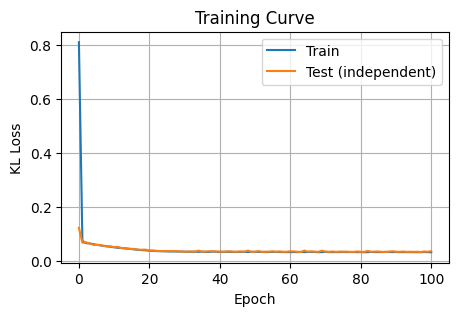

In [8]:
# ================================
# PLOT LOSS CURVE
# ================================
plt.figure(figsize=(5,3))
plt.plot(train_losses, label="Train")
plt.plot(test_losses, label="Test (independent)")
plt.xlabel("Epoch")
plt.ylabel("KL Loss")
plt.title("Training Curve")
plt.legend()
plt.grid()
plt.show()

In [9]:
# ================================
# EVALUATION FUNCTION
# ================================
def evaluate_model(model, X, Y):
    fids, l1s, kls = [], [], []
    model.eval()
    with torch.no_grad():
        for i in range(len(X)):
            pred = model(torch.tensor(X[i],dtype=torch.float32).unsqueeze(0)).numpy().flatten()
            true = Y[i]
            fids.append(fidelity(true,pred))
            l1s.append(l1_error(true,pred))
            kls.append(kl_divergence(true,pred))
    return np.array(fids), np.array(l1s), np.array(kls)

fids_ind, l1_ind, kl_ind = evaluate_model(model_base, X_test_ind, Y_test_ind)
fids_zz, l1_zz, kl_zz = evaluate_model(model_base, X_test_zz, Y_test_zz)
fids_mix, l1_mix, kl_mix = evaluate_model(model_base, X_test_combined, Y_test_combined)
# RZZ Correlated: 
# کاهش فضای حالت موثر
# توزیع حالات تمرکز بیشتری پیدا می کند
print("\n===== TEST METRICS =====\n")
print(f"{'Dataset':<15} | {'Fidelity':<10} | {'L1 Error':<10} | {'KL Divergence':<12}")
print("-"*58)
print(f"{'Independent':<15} | {np.mean(fids_ind):<10.4f} | {np.mean(l1_ind):<10.4f} | {np.mean(kl_ind):<12.4f}")
print(f"{'RZZ Correlated':<15} | {np.mean(fids_zz):<10.4f} | {np.mean(l1_zz):<10.4f} | {np.mean(kl_zz):<12.4f}")
print(f"{'Combined':<15} | {np.mean(fids_mix):<10.4f} | {np.mean(l1_mix):<10.4f} | {np.mean(kl_mix):<12.4f}")


===== TEST METRICS =====

Dataset         | Fidelity   | L1 Error   | KL Divergence
----------------------------------------------------------
Independent     | 0.9784     | 0.1583     | 0.0367      
RZZ Correlated  | 0.9786     | 0.1572     | 0.0365      
Combined        | 0.9785     | 0.1578     | 0.0366      


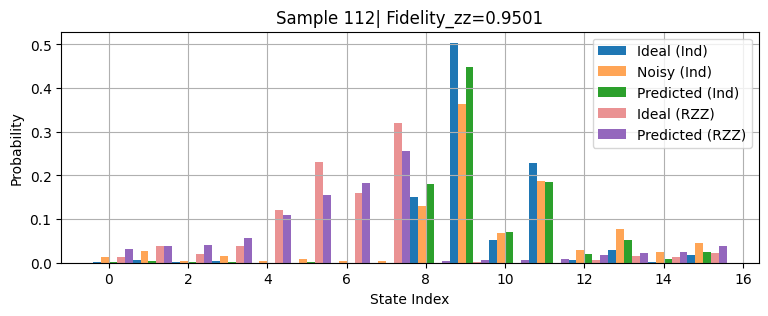

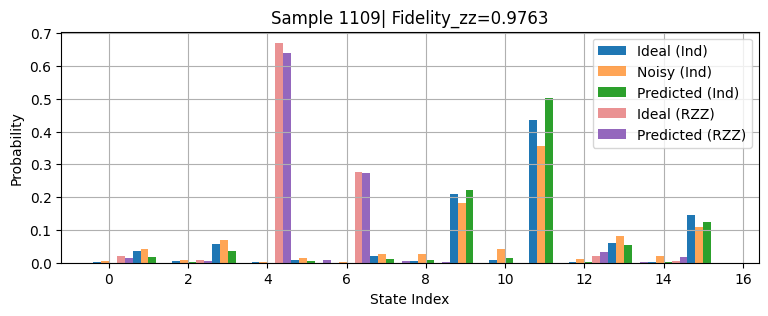

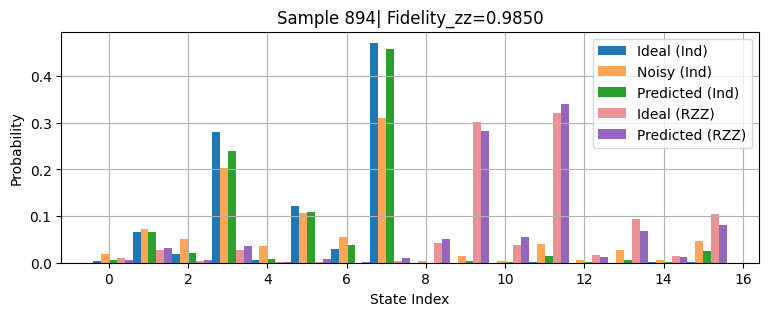

In [10]:
# ================================
# VISUAL COMPARISON (SAMPLE)
# ================================
indices = np.random.choice(len(X_test_ind), 3, replace=False)
for idx in indices:
    x_axis = np.arange(16)
    pred_ind = model_base(torch.tensor(X_test_ind[idx],dtype=torch.float32).unsqueeze(0)).detach().numpy().flatten()
    pred_zz  = model_base(torch.tensor(X_test_zz[idx],dtype=torch.float32).unsqueeze(0)).detach().numpy().flatten()
    true = Y_test_zz[idx]
    f = fidelity(true, pred_zz)
    width = 0.2
    plt.figure(figsize=(9,3))
    plt.bar(x_axis - 1.5*width, Y_test_ind[idx], width=width, label="Ideal (Ind)")
    plt.bar(x_axis - 0.5*width, X_test_ind[idx], width=width, alpha=0.7, label="Noisy (Ind)")
    plt.bar(x_axis + 0.5*width, pred_ind, width=width, label="Predicted (Ind)")
    plt.bar(x_axis + 1.5*width, Y_test_zz[idx], width=width, alpha=0.5, label="Ideal (RZZ)")
    plt.bar(x_axis + 2.5*width, pred_zz, width=width, label="Predicted (RZZ)")
    plt.xlabel("State Index")
    plt.ylabel("Probability")
    plt.title(f"Sample {idx}| Fidelity_zz={f:.4f}")
    plt.legend()
    plt.grid()
    plt.show()

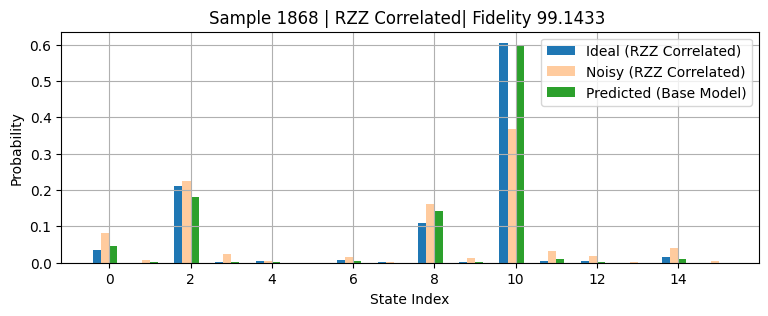

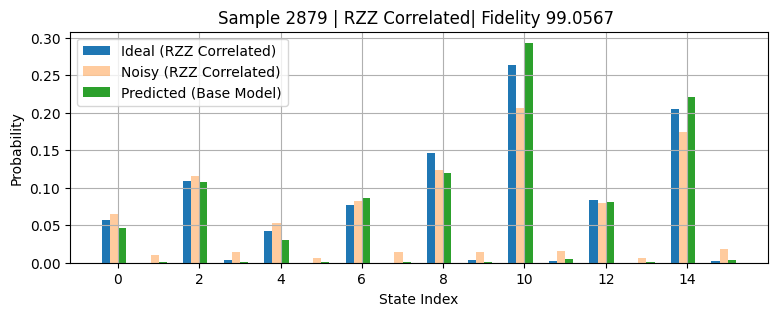

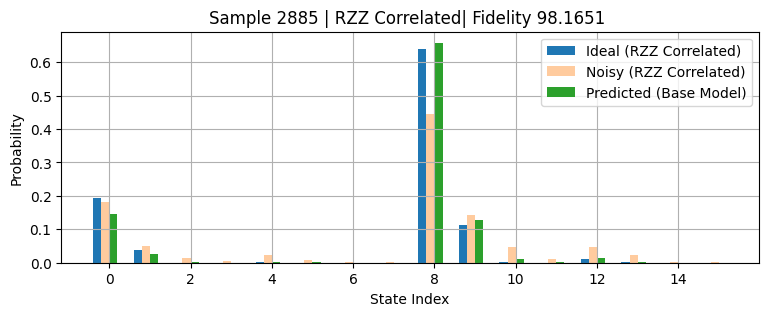

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# تعداد نمونه‌هایی که می‌خواهیم نمایش دهیم
num_samples_to_plot = 3
indices = np.random.choice(len(X_test_combined), size=num_samples_to_plot, replace=False)

x_axis = np.arange(16)
width = 0.2

for idx in indices:
    # تعیین نوع نمونه
    label_type = "Independent" if idx < 1000 else "RZZ Correlated"
    
    plt.figure(figsize=(9,3))
    # ستون‌های نمودار
    plt.bar(x_axis - 1.5*width, Y_test_combined[idx], width=width, label=f"Ideal ({label_type})")
    plt.bar(x_axis - 0.5*width, X_test_combined[idx], width=width, alpha=0.4, label=f"Noisy ({label_type})")
    
    # پیش‌بینی مدل پایه
    pred = model_base(torch.tensor(X_test_combined[idx], dtype=torch.float32).unsqueeze(0)).detach().numpy().flatten()
    f = fidelity(Y_test_combined[idx], pred)
    
    plt.bar(x_axis + 0.5*width, pred, width=width, label="Predicted (Base Model)")
    plt.xlabel("State Index")
    plt.ylabel("Probability")
    plt.title(f"Sample {idx} | {label_type}| Fidelity {100*f:.4f} ")
    plt.legend()
    plt.grid()
    plt.show()

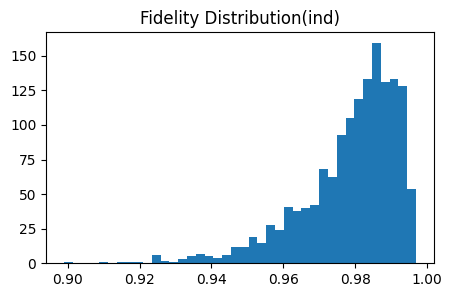

In [12]:
plt.figure(figsize=(5,3))
plt.hist(fids_ind, bins=40)
plt.title("Fidelity Distribution(ind)")
plt.show()

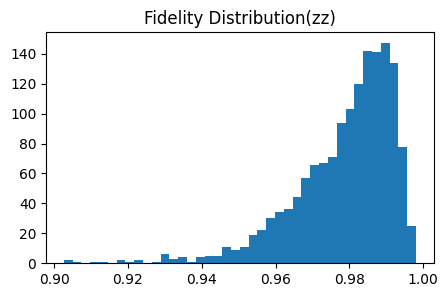

In [13]:
plt.figure(figsize=(5,3))
plt.hist(fids_zz, bins=40)
plt.title("Fidelity Distribution(zz)")
plt.show()

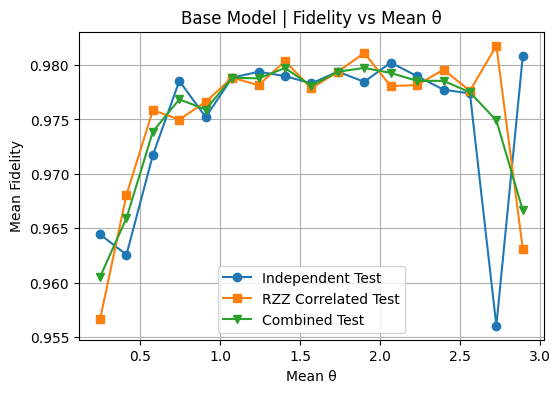

In [15]:
# ================================
# EVALUATION METRICS vs Base Model
# ================================
def compute_metric_vs_theta(X, Y, theta_array, model, metric='fidelity', num_bins=20):
    model.eval()
    values, theta_mean_list = [], []
    with torch.no_grad():
        for i in range(len(X)):
            x = torch.tensor(X[i],dtype=torch.float32).unsqueeze(0)
            pred = model(x).numpy().flatten()
            true = Y[i]
            theta_mean = np.mean(theta_array[i])
            theta_mean_list.append(theta_mean)
            if metric=='fidelity':
                values.append(fidelity(true,pred))
            elif metric=='kl':
                values.append(kl_divergence(true,pred))
    theta_mean_list = np.array(theta_mean_list)
    values = np.array(values)
    bins = np.linspace(0,np.pi,num_bins)
    bin_centers = 0.5*(bins[:-1]+bins[1:])
    values_binned = []
    for i in range(len(bins)-1):
        mask = (theta_mean_list>=bins[i]) & (theta_mean_list<bins[i+1])
        values_binned.append(np.mean(values[mask]) if np.any(mask) else np.nan)
    return bin_centers, np.array(values_binned)
# ================================

# Fidelity comparison

# محاسبه برای دیتاست مستقل
# ================================
bin_centers_ind, fid_binned_ind = compute_metric_vs_theta(X_test_ind, Y_test_ind, theta_test_ind, model_base, 'fidelity')
# ================================
# محاسبه برای دیتاست RZZ
# ================================
bin_centers_zz, fid_binned_zz = compute_metric_vs_theta(X_test_zz, Y_test_zz, theta_test_zz, model_base, 'fidelity')
# ================================
# محاسبه برای دیتاست ترکیبی combined
# ================================
bin_centers_mix,fid_binned_mix = compute_metric_vs_theta(X_test_combined, Y_test_combined, theta_test_combined, model_base, 'fidelity')
# ================================
# رسم نمودار مقایسه‌ای
# ================================
plt.figure(figsize=(6,4))
plt.plot(bin_centers_ind, fid_binned_ind, marker='o', label="Independent Test")
plt.plot(bin_centers_zz, fid_binned_zz, marker='s', label="RZZ Correlated Test")
plt.plot(bin_centers_mix, fid_binned_mix, marker='v', label="Combined Test")
plt.xlabel("Mean θ")
plt.ylabel("Mean Fidelity")
plt.title("Base Model | Fidelity vs Mean θ")
plt.legend()
plt.grid(True)
plt.show()

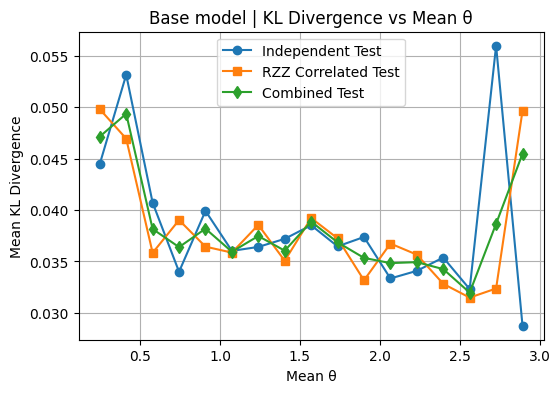

In [16]:
# ================================
# محاسبه میانگین KL divergence بر اساس theta
# ================================

# ================================
# محاسبه برای دیتاست مستقل
# ================================
bin_centers_ind, kl_binned_ind = compute_metric_vs_theta(
    X_test_ind, Y_test_ind, theta_test_ind, model_base, 'kl'
)

# ================================
# محاسبه برای دیتاست RZZ
# ================================
bin_centers_zz, kl_binned_zz = compute_metric_vs_theta(
    X_test_zz, Y_test_zz, theta_test_zz, model_base, 'kl'
)
# ================================
# محاسبه برای دیتاست ترکیبی combined
# ================================
bin_centers_mix, kl_binned_mix = compute_metric_vs_theta(
    X_test_combined, Y_test_combined, theta_test_combined, model_base, 'kl'
)
# ================================
# رسم نمودار مقایسه‌ای KL
# ================================
plt.figure(figsize=(6,4))
plt.plot(bin_centers_ind, kl_binned_ind, marker='o', label="Independent Test")
plt.plot(bin_centers_zz, kl_binned_zz, marker='s', label="RZZ Correlated Test")
plt.plot(bin_centers_mix, kl_binned_mix, marker='d', label="Combined Test")
plt.xlabel("Mean θ")
plt.ylabel("Mean KL Divergence")
plt.title("Base model | KL Divergence vs Mean θ")
plt.legend()
plt.grid(True)
plt.show()

## Train / Validation / Test

In [17]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, ReadoutError
import matplotlib.pyplot as plt
# ================================
# METRICS
# ================================
def fidelity(p, q):
    return (np.sum(np.sqrt(p * q)))**2

def kl_divergence(p, q):
    return np.sum(p * np.log((p + 1e-10) / (q + 1e-10)))
# ================================
# CIRCUITS
# ================================
def build_circuit_independent(thetas):
    qc = QuantumCircuit(4, 4)
    for i in range(4):
        qc.ry(thetas[i], i)
    qc.measure([0,1,2,3], [0,1,2,3])
    return qc

def build_correlated_circuit_rzz(thetas, theta_rzz=np.pi/2):
    qc = build_circuit_independent(thetas)
    for j in range(4):
        for k in range(j+1, 4):
            qc.rzz(theta_rzz, j, k)
    qc.measure([0,1,2,3], [0,1,2,3])
    return qc

def counts_to_probs_4q(counts):
    probs = np.zeros(16)
    for bitstring, count in counts.items():
        idx = int(bitstring, 2)
        probs[idx] = count
    return probs / np.sum(probs)

# ================================
# NOISE MODEL
# ================================
def create_noise_model(p01, p10):
    noise_model = NoiseModel()
    readout_error = ReadoutError([[1-p01, p01],[p10, 1-p10]])
    for q in range(4):
        noise_model.add_readout_error(readout_error, [q])
    return noise_model
# ================================
# SIMULATION
# ================================
ideal_sim = AerSimulator()

def get_probs(qc_func, thetas, noise_model=None, shots=1024):
    qc = qc_func(thetas)
    sim = AerSimulator(noise_model=noise_model)
    result = sim.run(qc, shots=shots).result()
    counts = result.get_counts()
    return counts_to_probs_4q(counts)
# ================================
# DATASET GENERATOR
# ================================
def generate_dataset(num_samples, qc_func, theta_range=(0, np.pi), noise_range=(0.05,0.15)):
    X, Y, Theta = [], [], []
    for _ in range(num_samples):
        thetas = np.random.uniform(theta_range[0], theta_range[1], size=4)
        p01, p10 = np.random.uniform(noise_range[0], noise_range[1], size=2)
        noise_model = create_noise_model(p01, p10)
        p_ideal = get_probs(qc_func, thetas, noise_model=None)
        p_noisy = get_probs(qc_func, thetas, noise_model=noise_model)
        X.append(p_noisy)
        Y.append(p_ideal)
        Theta.append(thetas)
    return np.array(X), np.array(Y), np.array(Theta)

In [18]:
# ================================
# GENERATE TRAIN / VALIDATION / TEST
# ================================
print("Generating TRAIN dataset (independent)...")
# مستقل
X_train_ind, Y_train_ind, theta_train_ind = generate_dataset(3500, build_circuit_independent)
# correlated
X_train_zz, Y_train_zz, theta_train_zz = generate_dataset(1500, build_correlated_circuit_rzz)

# ترکیب
X_train = np.vstack([X_train_ind, X_train_zz])
Y_train = np.vstack([Y_train_ind, Y_train_zz])
theta_train = np.vstack([theta_train_ind, theta_train_zz])

print("Generating VALIDATION dataset (mixed)...")
# ترکیبی: 80% مستقل + 20% correlated
X_val_ind, Y_val_ind, theta_val_ind = generate_dataset(1000, build_circuit_independent)
X_val_zz, Y_val_zz, theta_val_zz = generate_dataset(500, build_correlated_circuit_rzz)

X_val = np.vstack([X_val_ind, X_val_zz])
Y_val = np.vstack([Y_val_ind, Y_val_zz])
theta_val = np.vstack([theta_val_ind, theta_val_zz])

Generating TRAIN dataset (independent)...
Generating VALIDATION dataset (mixed)...


In [20]:
# save dataset related to model_mlp
# ================================
# ذخیره دیتای آموزش (train)
# ================================
np.savetxt("X_train_mlp.txt", X_train.reshape(X_train.shape[0], -1))
np.savetxt("Y_train_mlp.txt", Y_train.reshape(Y_train.shape[0], -1))
np.savetxt("theta_train_mlp.txt", theta_train)

# ================================
# ذخیره دیتای تست مستقل (Independent)
# ================================
# np.savetxt("X_test_ind_mlp.txt", X_test_ind.reshape(X_test_ind.shape[0], -1))
# np.savetxt("Y_test_ind_mlp.txt", Y_test_ind.reshape(Y_test_ind.shape[0], -1))
# np.savetxt("theta_test_ind_mlp.txt", theta_test_ind)

# ================================
# ذخیره دیتای تست همبسته (RZZ Correlated)
# ================================
# np.savetxt("X_test_zz_mlp.txt", X_test_zz.reshape(X_test_zz.shape[0], -1))
# np.savetxt("Y_test_zz_mlp.txt", Y_test_zz.reshape(Y_test_zz.shape[0], -1))
# np.savetxt("theta_test_zz_mlp.txt", theta_test_zz)

# ================================
# ذخیره دیتای تست ترکیبی (Combined)
# ================================
# np.savetxt("X_test_combined_mlp.txt", X_test_combined.reshape(X_test_combined.shape[0], -1))
# np.savetxt("Y_test_combined_mlp.txt", Y_test_combined.reshape(Y_test_combined.shape[0], -1))
# np.savetxt("theta_test_combined_mlp.txt", theta_test_combined)

In [21]:
# ================================
# بارگذاری داده‌ها برای استفاده در مدل جدید
# ================================
X_train_mlp = np.loadtxt("X_train_mlp.txt").reshape(-1, 16)
Y_train_mlp = np.loadtxt("Y_train_mlp.txt").reshape(-1, 16)
theta_train_mlp = np.loadtxt("theta_train_mlp.txt").reshape(-1, 4)

# X_val = np.loadtxt("X_val_mlp.txt").reshape(-1, 16)
# Y_val = np.loadtxt("Y_val_mlp.txt").reshape(-1, 16)
# theta_val = np.loadtxt("theta_val_mlp.txt").reshape(-1, 4)

# X_test_ind_mlp = np.loadtxt("X_test_ind_mlp.txt").reshape(-1, 16)
# Y_test_ind_mlp = np.loadtxt("Y_test_ind_mlp.txt").reshape(-1, 16)
# theta_test_ind_mlp = np.loadtxt("theta_test_ind_mlp.txt").reshape(-1, 4)

# X_test_zz_mlp = np.loadtxt("X_test_zz_mlp.txt").reshape(-1, 16)
# Y_test_zz_mlp = np.loadtxt("Y_test_zz_mlp.txt").reshape(-1, 16)
# theta_test_zz_mlp = np.loadtxt("theta_test_zz_mlp.txt").reshape(-1, 4)

# X_test_combined_mlp = np.loadtxt("X_test_combined_mlp.txt").reshape(-1, 16)
# Y_test_combined_mlp = np.loadtxt("Y_test_combined_mlp.txt").reshape(-1, 16)
# theta_test_combined_mlp = np.loadtxt("theta_test_combined_mlp.txt").reshape(-1, 4)

In [22]:
print("Loading TEST dataset (same as base model)...")
X_test_ind = np.loadtxt("X_test_ind.txt").reshape(-1,16)
Y_test_ind = np.loadtxt("Y_test_ind.txt").reshape(-1,16)
theta_test_ind = np.loadtxt("theta_test_ind.txt").reshape(-1,4)

X_test_zz = np.loadtxt("X_test_zz.txt").reshape(-1,16)
Y_test_zz = np.loadtxt("Y_test_zz.txt").reshape(-1,16)
theta_test_zz = np.loadtxt("theta_test_zz.txt").reshape(-1,4)

X_test_combined = np.loadtxt("X_test_combined.txt").reshape(-1,16)
Y_test_combined = np.loadtxt("Y_test_combined.txt").reshape(-1,16)
theta_test_combined = np.loadtxt("theta_test_combined.txt").reshape(-1,4)

Loading TEST dataset (same as base model)...


In [23]:
# ================================
# DATA LOADERS
# ================================
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_mlp,dtype=torch.float32),
                  torch.tensor(Y_train_mlp,dtype=torch.float32)),
    batch_size=64, shuffle=True
)

val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val,dtype=torch.float32),
                  torch.tensor(Y_val,dtype=torch.float32)),
    batch_size=64, shuffle=False
)

In [24]:
# ================================
# MODEL
# ================================
class MLP_4Q(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(16,128), nn.ReLU(),
            nn.Linear(128,256), nn.ReLU(),
            nn.Linear(256,128), nn.ReLU(),
            nn.Linear(128,16), nn.Softmax(dim=1)
        )
    def forward(self, x):
        return self.net(x)

model_mlp = MLP_4Q()
criterion = nn.KLDivLoss(reduction="batchmean")
optimizer = optim.Adam(model_mlp.parameters(), lr=1e-3)


In [25]:
# ================================
# TRAINING WITH VALIDATION
# ================================
epochs = 101
train_losses, val_losses = [], []

for epoch in range(epochs):
    # train
    model_mlp.train()
    total_loss = 0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model_mlp(x_batch)
        loss = criterion(torch.log(preds+1e-8), y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_losses.append(total_loss/len(train_loader))
    
    # validation
    model_mlp.eval()
    val_loss = 0
    with torch.no_grad():
        for x_val, y_val in val_loader:
            preds_val = model_mlp(x_val)
            loss_val = criterion(torch.log(preds_val+1e-8), y_val)
            val_loss += loss_val.item()
    val_losses.append(val_loss/len(val_loader))
    
    if epoch % 5 == 0:
        print(f"Epoch {epoch}: Train={train_losses[-1]:.5f}, Val={val_losses[-1]:.5f}")

Epoch 0: Train=0.77517, Val=0.09236
Epoch 5: Train=0.05969, Val=0.06037
Epoch 10: Train=0.05083, Val=0.05217
Epoch 15: Train=0.04411, Val=0.04431
Epoch 20: Train=0.03958, Val=0.04127
Epoch 25: Train=0.03581, Val=0.03665
Epoch 30: Train=0.03482, Val=0.03579
Epoch 35: Train=0.03363, Val=0.03453
Epoch 40: Train=0.03341, Val=0.03404
Epoch 45: Train=0.03411, Val=0.03711
Epoch 50: Train=0.03345, Val=0.03431
Epoch 55: Train=0.03315, Val=0.03446
Epoch 60: Train=0.03261, Val=0.03488
Epoch 65: Train=0.03259, Val=0.03303
Epoch 70: Train=0.03250, Val=0.03333
Epoch 75: Train=0.03237, Val=0.03403
Epoch 80: Train=0.03293, Val=0.03499
Epoch 85: Train=0.03217, Val=0.03423
Epoch 90: Train=0.03226, Val=0.03365
Epoch 95: Train=0.03286, Val=0.03323
Epoch 100: Train=0.03207, Val=0.03505


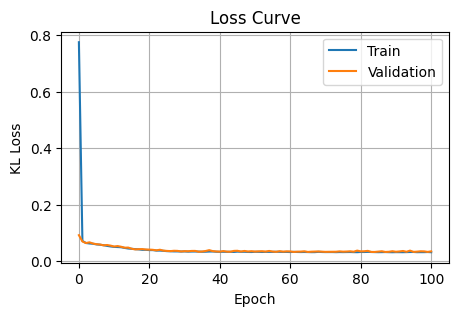

In [26]:
# ================================
# PLOT LOSS
# ================================
plt.figure(figsize=(5,3))
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("KL Loss")
plt.legend()
plt.grid(True)
plt.title("Loss Curve")
plt.show()

In [29]:
fids_ind_mlp, l1_ind_mlp, kl_ind_mlp = evaluate_model(model_mlp, X_test_ind, Y_test_ind)
fids_zz_mlp, l1_zz_mlp, kl_zz_mlp = evaluate_model(model_mlp, X_test_zz, Y_test_zz)
fids_mix_mlp, l1_mix_mlp, kl_mix_mlp = evaluate_model(model_mlp, X_test_combined, Y_test_combined)
# RZZ Correlated: 
# کاهش فضای حالت موثر
# توزیع حالات تمرکز بیشتری پیدا می کند
print("\n===== TEST METRICS =====\n")
print(f"{'Dataset':<15} | {'Fidelity':<10} | {'L1 Error':<10} | {'KL Divergence':<12}")
print("-"*58)
print(f"{'Independent':<15} | {np.mean(fids_ind_mlp):<10.4f} | {np.mean(l1_ind_mlp):<10.4f} | {np.mean(kl_ind_mlp):<12.4f}")
print(f"{'RZZ Correlated':<15} | {np.mean(fids_zz_mlp):<10.4f} | {np.mean(l1_zz_mlp):<10.4f} | {np.mean(kl_zz_mlp):<12.4f}")
print(f"{'Combined':<15} | {np.mean(fids_mix_mlp):<10.4f} | {np.mean(l1_mix_mlp):<10.4f} | {np.mean(kl_mix_mlp):<12.4f}")


===== TEST METRICS =====

Dataset         | Fidelity   | L1 Error   | KL Divergence
----------------------------------------------------------
Independent     | 0.9791     | 0.1505     | 0.0350      
RZZ Correlated  | 0.9793     | 0.1516     | 0.0349      
Combined        | 0.9792     | 0.1510     | 0.0349      


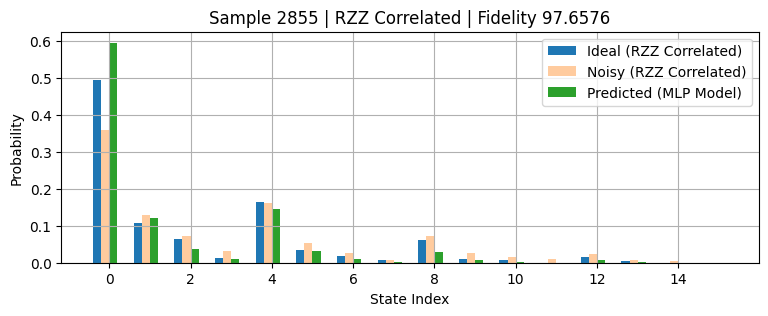

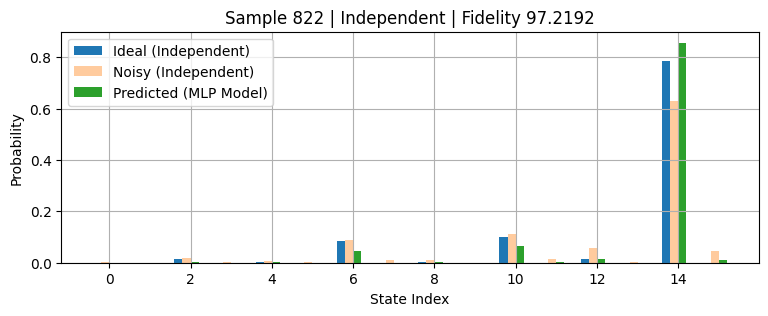

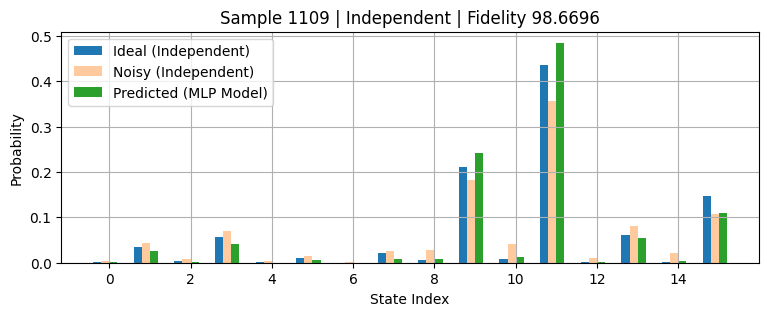

In [30]:
num_samples_to_plot = 3
indices = np.random.choice(len(X_test_combined), size=num_samples_to_plot, replace=False)

x_axis = np.arange(16)
width = 0.2

for idx in indices:
    # تعیین نوع نمونه
    label_type = "Independent" if idx < len(X_test_ind) else "RZZ Correlated"
    
    plt.figure(figsize=(9,3))
    # ستون‌های نمودار
    plt.bar(x_axis - 1.5*width, Y_test_combined[idx], width=width, label=f"Ideal ({label_type})")
    plt.bar(x_axis - 0.5*width, X_test_combined[idx], width=width, alpha=0.4, label=f"Noisy ({label_type})")
    
    # پیش‌بینی مدل MLP
    pred = model_mlp(torch.tensor(X_test_combined[idx], dtype=torch.float32).unsqueeze(0)).detach().numpy().flatten()
    f = fidelity(Y_test_combined[idx], pred)
    
    plt.bar(x_axis + 0.5*width, pred, width=width, label="Predicted (MLP Model)")
    plt.xlabel("State Index")
    plt.ylabel("Probability")
    plt.title(f"Sample {idx} | {label_type} | Fidelity {100*f:.4f}")
    plt.legend()
    plt.grid()
    plt.show()

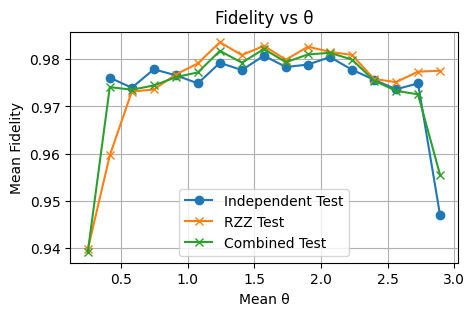

In [97]:
# ================================
# EVALUATION METRICS vs Base Model
# ================================

# Fidelity comparison
# ================================
bin_ind, fid_ind = compute_metric_vs_theta(X_test_ind, Y_test_ind, theta_test_ind, model_mlp, 'fidelity')
bin_zz, fid_zz = compute_metric_vs_theta(X_test_zz, Y_test_zz_mlp, theta_test_zz, model_mlp, 'fidelity')
bin_mix, fid_mix = compute_metric_vs_theta(X_test_combined, Y_test_combined, theta_test_combined, model_mlp, 'fidelity')

plt.figure(figsize=(5,3))
plt.plot(bin_ind, fid_ind, marker='o', label="Independent Test")
plt.plot(bin_zz, fid_zz, marker='x', label="RZZ Test")
plt.plot(bin_centers_mix, fid_binned_mix, marker='x', label="Combined Test")
plt.xlabel("Mean θ")
plt.ylabel("Mean Fidelity")
plt.title("Fidelity vs θ")
plt.grid(True)
plt.legend()
plt.show()

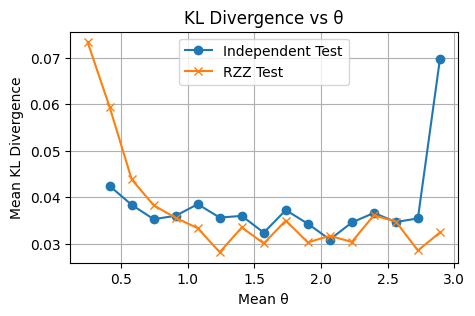

In [98]:
# ================================
# KL comparison
# ================================
bin_ind, kl_ind = compute_metric_vs_theta(X_test_ind, Y_test_ind, theta_test_ind, model_mlp, 'kl')
bin_zz, kl_zz = compute_metric_vs_theta(X_test_zz, Y_test_zz, theta_test_zz, model_mlp, 'kl')

plt.figure(figsize=(5,3))
plt.plot(bin_ind, kl_ind, marker='o', label="Independent Test")
plt.plot(bin_zz, kl_zz, marker='x', label="RZZ Test")
plt.xlabel("Mean θ")
plt.ylabel("Mean KL Divergence")
plt.title("KL Divergence vs θ")
plt.grid(True)
plt.legend()
plt.show()

In [31]:
fidelities, l1_errors, kl_values = [], [], []

model_mlp.eval()
with torch.no_grad():
    for i in range(len(X_test_combined)):
        pred = model_mlp(torch.tensor(X_test_combined[i], dtype=torch.float32).unsqueeze(0)).numpy().flatten()
        true = Y_test_combined[i]

        fidelities.append(fidelity(true, pred))
        l1_errors.append(l1_error(true, pred))
        kl_values.append(kl_divergence(true, pred))

print("\n===== TEST METRICS =====")
print("Avg Fidelity:", np.mean(fidelities))
print("Avg L1:", np.mean(l1_errors))
print("Avg KL:", np.mean(kl_values))


===== TEST METRICS =====
Avg Fidelity: 0.9791692747701345
Avg L1: 0.15102438781053823
Avg KL: 0.034911901484691525


## Compare model_base vs model_mlp

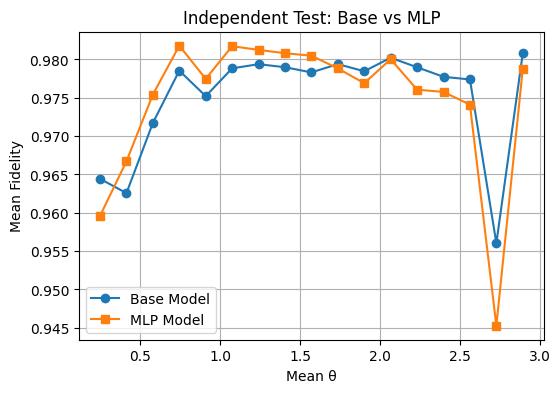

In [37]:
## Independent data
bin_ind_base, fid_ind_base = compute_metric_vs_theta(
    X_test_ind, Y_test_ind, theta_test_ind, model_base, 'fidelity'
)
bin_ind_mlp, fid_ind_mlp = compute_metric_vs_theta(
    X_test_ind, Y_test_ind, theta_test_ind, model_mlp, 'fidelity'
)

plt.figure(figsize=(6,4))
plt.plot(bin_ind_base, fid_ind_base, marker='o', label="Base Model")
plt.plot(bin_ind_mlp, fid_ind_mlp, marker='s', label="MLP Model")
plt.xlabel("Mean θ")
plt.ylabel("Mean Fidelity")
plt.title("Independent Test: Base vs MLP")
plt.grid(True)
plt.legend()
plt.show()

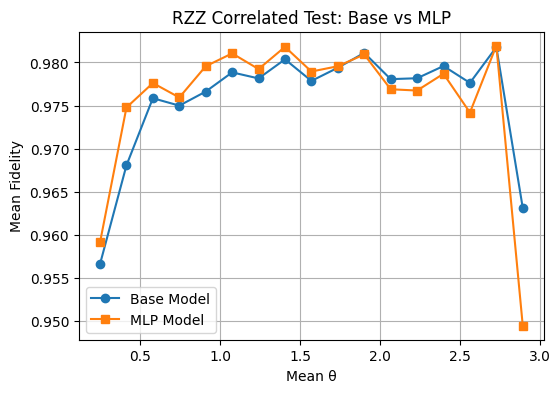

In [38]:
## ZZ data

bin_zz_base, fid_zz_base = compute_metric_vs_theta(
    X_test_zz, Y_test_zz, theta_test_zz, model_base, 'fidelity'
)
bin_zz_mlp, fid_zz_mlp = compute_metric_vs_theta(
    X_test_zz, Y_test_zz, theta_test_zz, model_mlp, 'fidelity'
)

plt.figure(figsize=(6,4))
plt.plot(bin_zz_base, fid_zz_base, marker='o', label="Base Model")
plt.plot(bin_zz_mlp, fid_zz_mlp, marker='s', label="MLP Model")
plt.xlabel("Mean θ")
plt.ylabel("Mean Fidelity")
plt.title("RZZ Correlated Test: Base vs MLP")
plt.grid(True)
plt.legend()
plt.show()

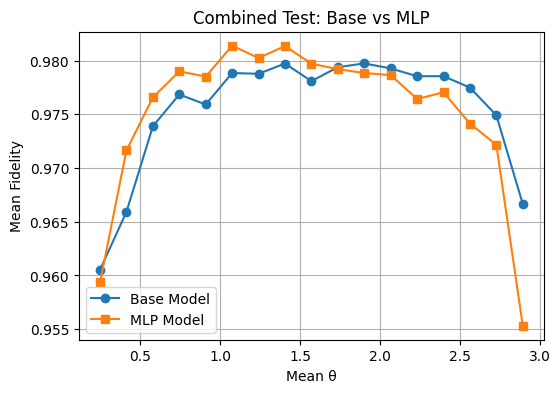

In [39]:
## combined data
bin_comb_base, fid_comb_base = compute_metric_vs_theta(
    X_test_combined, Y_test_combined, theta_test_combined, model_base, 'fidelity'
)
bin_comb_mlp, fid_comb_mlp = compute_metric_vs_theta(
    X_test_combined, Y_test_combined, theta_test_combined, model_mlp, 'fidelity'
)

plt.figure(figsize=(6,4))
plt.plot(bin_comb_base, fid_comb_base, marker='o', label="Base Model")
plt.plot(bin_comb_mlp, fid_comb_mlp, marker='s', label="MLP Model")
plt.xlabel("Mean θ")
plt.ylabel("Mean Fidelity")
plt.title("Combined Test: Base vs MLP")
plt.grid(True)
plt.legend()
plt.show()

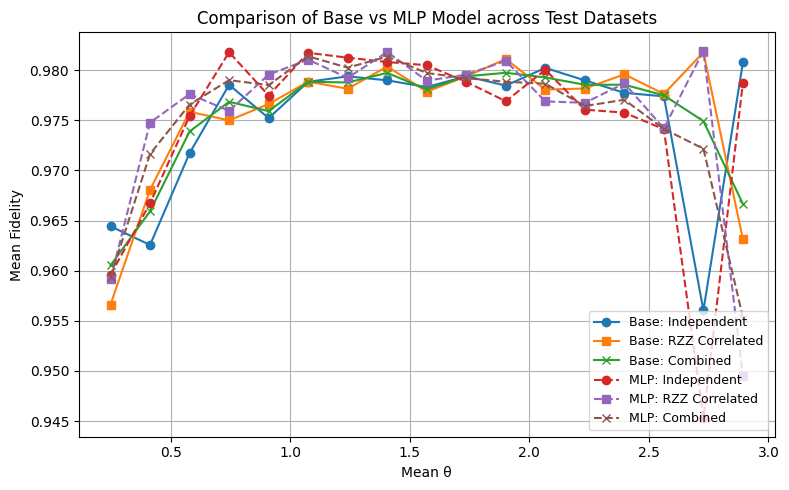

In [40]:
plt.figure(figsize=(8,5))

# Base Model
plt.plot(bin_ind_base, fid_ind_base, marker='o', linestyle='-', label="Base: Independent")
plt.plot(bin_zz_base, fid_zz_base, marker='s', linestyle='-', label="Base: RZZ Correlated")
plt.plot(bin_comb_base, fid_comb_base, marker='x', linestyle='-', label="Base: Combined")

# MLP Model
plt.plot(bin_ind_mlp, fid_ind_mlp, marker='o', linestyle='--', label="MLP: Independent")
plt.plot(bin_zz_mlp, fid_zz_mlp, marker='s', linestyle='--', label="MLP: RZZ Correlated")
plt.plot(bin_comb_mlp, fid_comb_mlp, marker='x', linestyle='--', label="MLP: Combined")

plt.xlabel("Mean θ")
plt.ylabel("Mean Fidelity")
plt.title("Comparison of Base vs MLP Model across Test Datasets")
plt.grid(True)
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

In [43]:
# محاسبه متریک‌ها برای Base Model
fids_ind_base, l1_ind_base, kl_ind_base = evaluate_model(model_base, X_test_ind, Y_test_ind)
fids_zz_base, l1_zz_base, kl_zz_base = evaluate_model(model_base, X_test_zz, Y_test_zz)
fids_mix_base, l1_mix_base, kl_mix_base = evaluate_model(model_base, X_test_combined, Y_test_combined)

# محاسبه متریک‌ها برای MLP Model
fids_ind_mlp, l1_ind_mlp, kl_ind_mlp = evaluate_model(model_mlp, X_test_ind, Y_test_ind)
fids_zz_mlp, l1_zz_mlp, kl_zz_mlp = evaluate_model(model_mlp, X_test_zz, Y_test_zz)
fids_mix_mlp, l1_mix_mlp, kl_mix_mlp = evaluate_model(model_mlp, X_test_combined, Y_test_combined)

# نمایش جدول مقایسه‌ای
print("\n===== COMPARISON: Base Model vs MLP Model =====\n")
header = f"{'Dataset':<15} | {'Metric':<10} | {'Base Model':<12} | {'MLP Model':<12}"
print(header)
print("-"*len(header))

datasets = ["Independent", "RZZ Correlated", "Combined"]
metrics = ["Fidelity", "L1 Error", "KL Divergence"]

for ds, f_base, f_mlp, l1_base, l1_mlp, kl_base, kl_mlp in zip(
    datasets,
    [np.mean(fids_ind_base), np.mean(fids_zz_base), np.mean(fids_mix_base)],
    [np.mean(fids_ind_mlp), np.mean(fids_zz_mlp), np.mean(fids_mix_mlp)],
    [np.mean(l1_ind_base), np.mean(l1_zz_base), np.mean(l1_mix_base)],
    [np.mean(l1_ind_mlp), np.mean(l1_zz_mlp), np.mean(l1_mix_mlp)],
    [np.mean(kl_ind_base), np.mean(kl_zz_base), np.mean(kl_mix_base)],
    [np.mean(kl_ind_mlp), np.mean(kl_zz_mlp), np.mean(kl_mix_mlp)]
):
    print(f"{ds:<15} | {metrics[0]:<13} | {f_base:<12.4f} | {f_mlp:<12.4f}")
    print(f"{'':<15} | {metrics[1]:<13} | {l1_base:<12.4f} | {l1_mlp:<12.4f}")
    print(f"{'':<15} | {metrics[2]:<13} | {kl_base:<12.4f} | {kl_mlp:<12.4f}")
    print("-"*len(header))


===== COMPARISON: Base Model vs MLP Model =====

Dataset         | Metric     | Base Model   | MLP Model   
----------------------------------------------------------
Independent     | Fidelity      | 0.9784       | 0.9791      
                | L1 Error      | 0.1583       | 0.1505      
                | KL Divergence | 0.0367       | 0.0350      
----------------------------------------------------------
RZZ Correlated  | Fidelity      | 0.9786       | 0.9793      
                | L1 Error      | 0.1572       | 0.1516      
                | KL Divergence | 0.0365       | 0.0349      
----------------------------------------------------------
Combined        | Fidelity      | 0.9785       | 0.9792      
                | L1 Error      | 0.1578       | 0.1510      
                | KL Divergence | 0.0366       | 0.0349      
----------------------------------------------------------
